## Importing the libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import scipy.cluster.hierarchy as sch

plt.style.use('seaborn-v0_8-whitegrid')
print('Semua library berhasil diimport.')

Semua library berhasil diimport.


## Importing the dataset

In [16]:
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

print(f'Shape dataset: {dataset.shape}')
print(f'Jumlah data points: {X.shape[0]}')
print(f'Jumlah fitur: {X.shape[1]}')
print(f'\nKolom: {list(dataset.columns)}')
dataset.head(10)

Shape dataset: (200, 5)
Jumlah data points: 200
Jumlah fitur: 2

Kolom: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## Exploratory Data Analysis (EDA)

In [17]:
print('=== Statistik Deskriptif ===')
print(dataset.describe())
print(f'\n=== Cek Missing Values ===')
print(dataset.isnull().sum())
print(f'\n=== Distribusi Genre ===')
print(dataset['Genre'].value_counts())

=== Statistik Deskriptif ===
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

=== Cek Missing Values ===
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Distribusi Genre ===
Genre
Female    112
Male       88
Name: count, dtype: int64


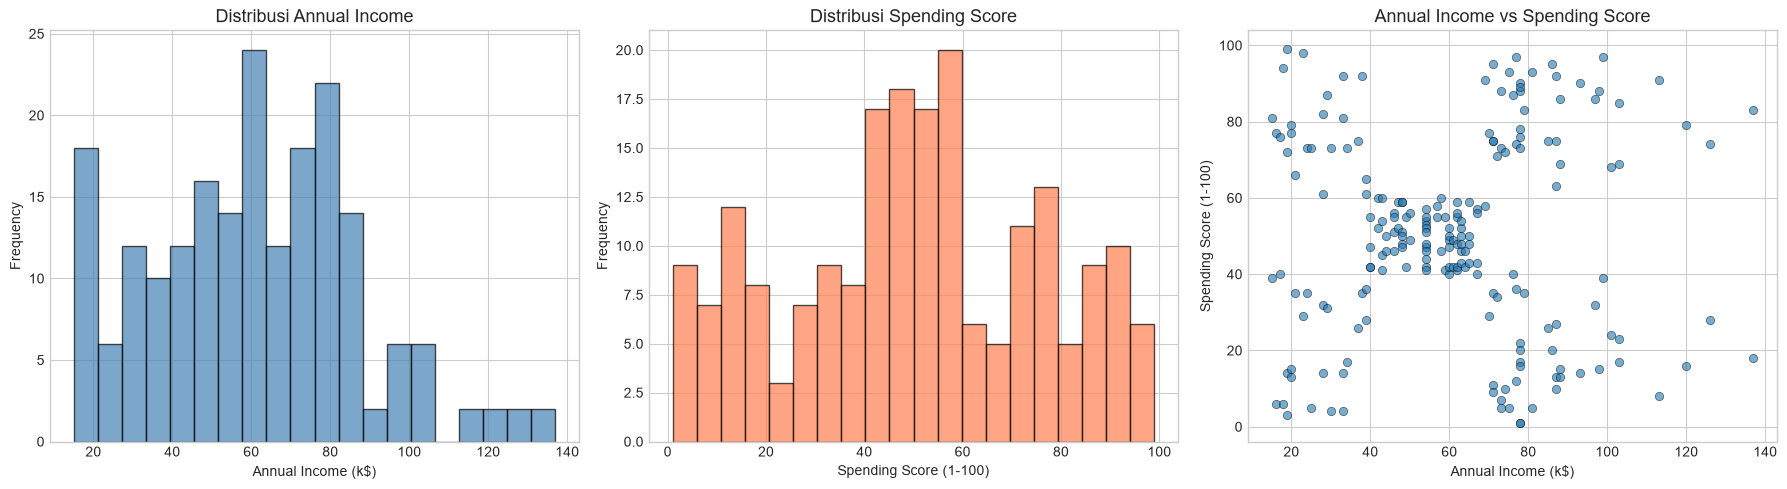

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(dataset['Annual Income (k$)'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Annual Income', fontsize=13)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Frequency')

axes[1].hist(dataset['Spending Score (1-100)'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Spending Score', fontsize=13)
axes[1].set_xlabel('Spending Score (1-100)')
axes[1].set_ylabel('Frequency')

axes[2].scatter(dataset['Annual Income (k$)'], dataset['Spending Score (1-100)'], alpha=0.6, edgecolors='black', linewidth=0.5)
axes[2].set_title('Annual Income vs Spending Score', fontsize=13)
axes[2].set_xlabel('Annual Income (k$)')
axes[2].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

## Feature Scaling

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Data sebelum scaling:')
print(f'  Mean: {X.mean(axis=0).round(2)}')
print(f'  Std : {X.std(axis=0).round(2)}')
print(f'\nData setelah scaling:')
print(f'  Mean: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std : {X_scaled.std(axis=0).round(4)}')

Data sebelum scaling:
  Mean: [60.56 50.2 ]
  Std : [26.2  25.76]

Data setelah scaling:
  Mean: [-0. -0.]
  Std : [1. 1.]


## Using the dendrogram to find the optimal number of clusters

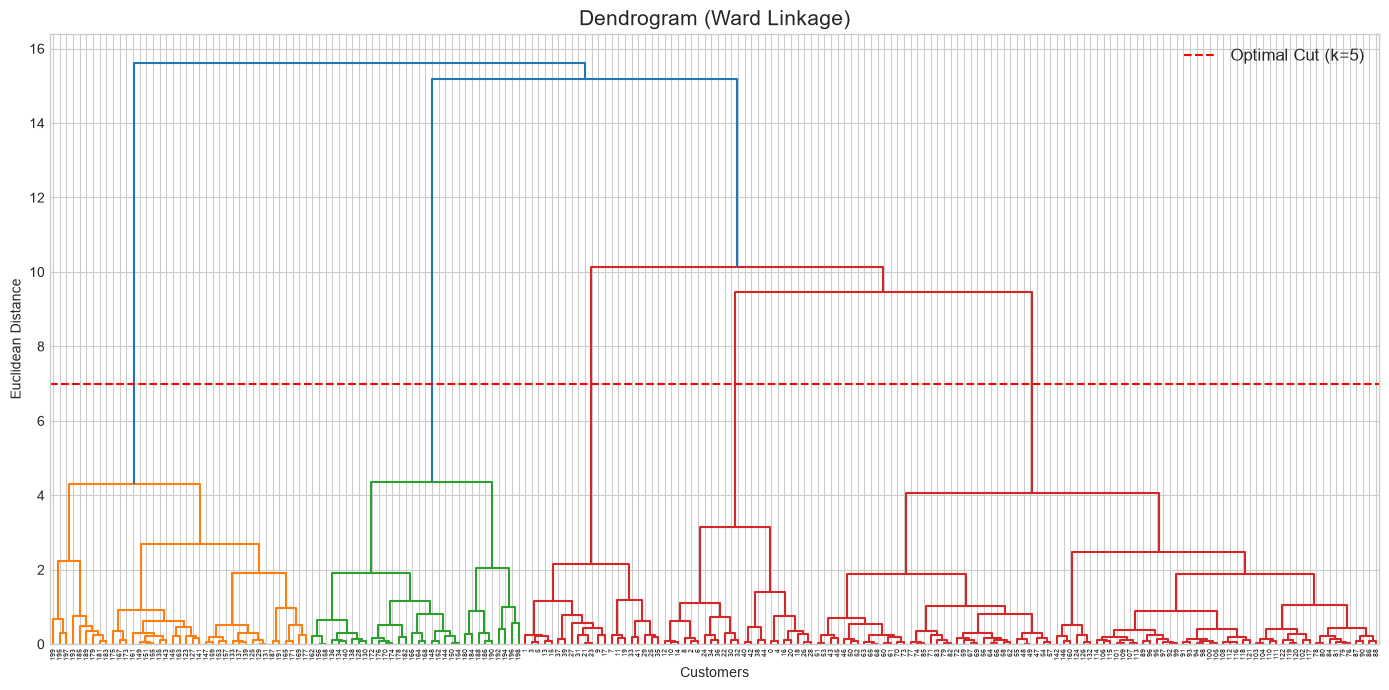

Interpretasi: Garis merah horizontal memotong dendrogram pada jarak sekitar 7.
Pemotongan ini menghasilkan 5 cluster (5 garis vertikal yang terpotong).


In [20]:
plt.figure(figsize=(14, 7))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram (Ward Linkage)', fontsize=15)
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.axhline(y=7, color='r', linestyle='--', label='Optimal Cut (k=5)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('Interpretasi: Garis merah horizontal memotong dendrogram pada jarak sekitar 7.')
print('Pemotongan ini menghasilkan 5 cluster (5 garis vertikal yang terpotong).')

### Perbandingan Dendrogram dengan Berbagai Linkage Method

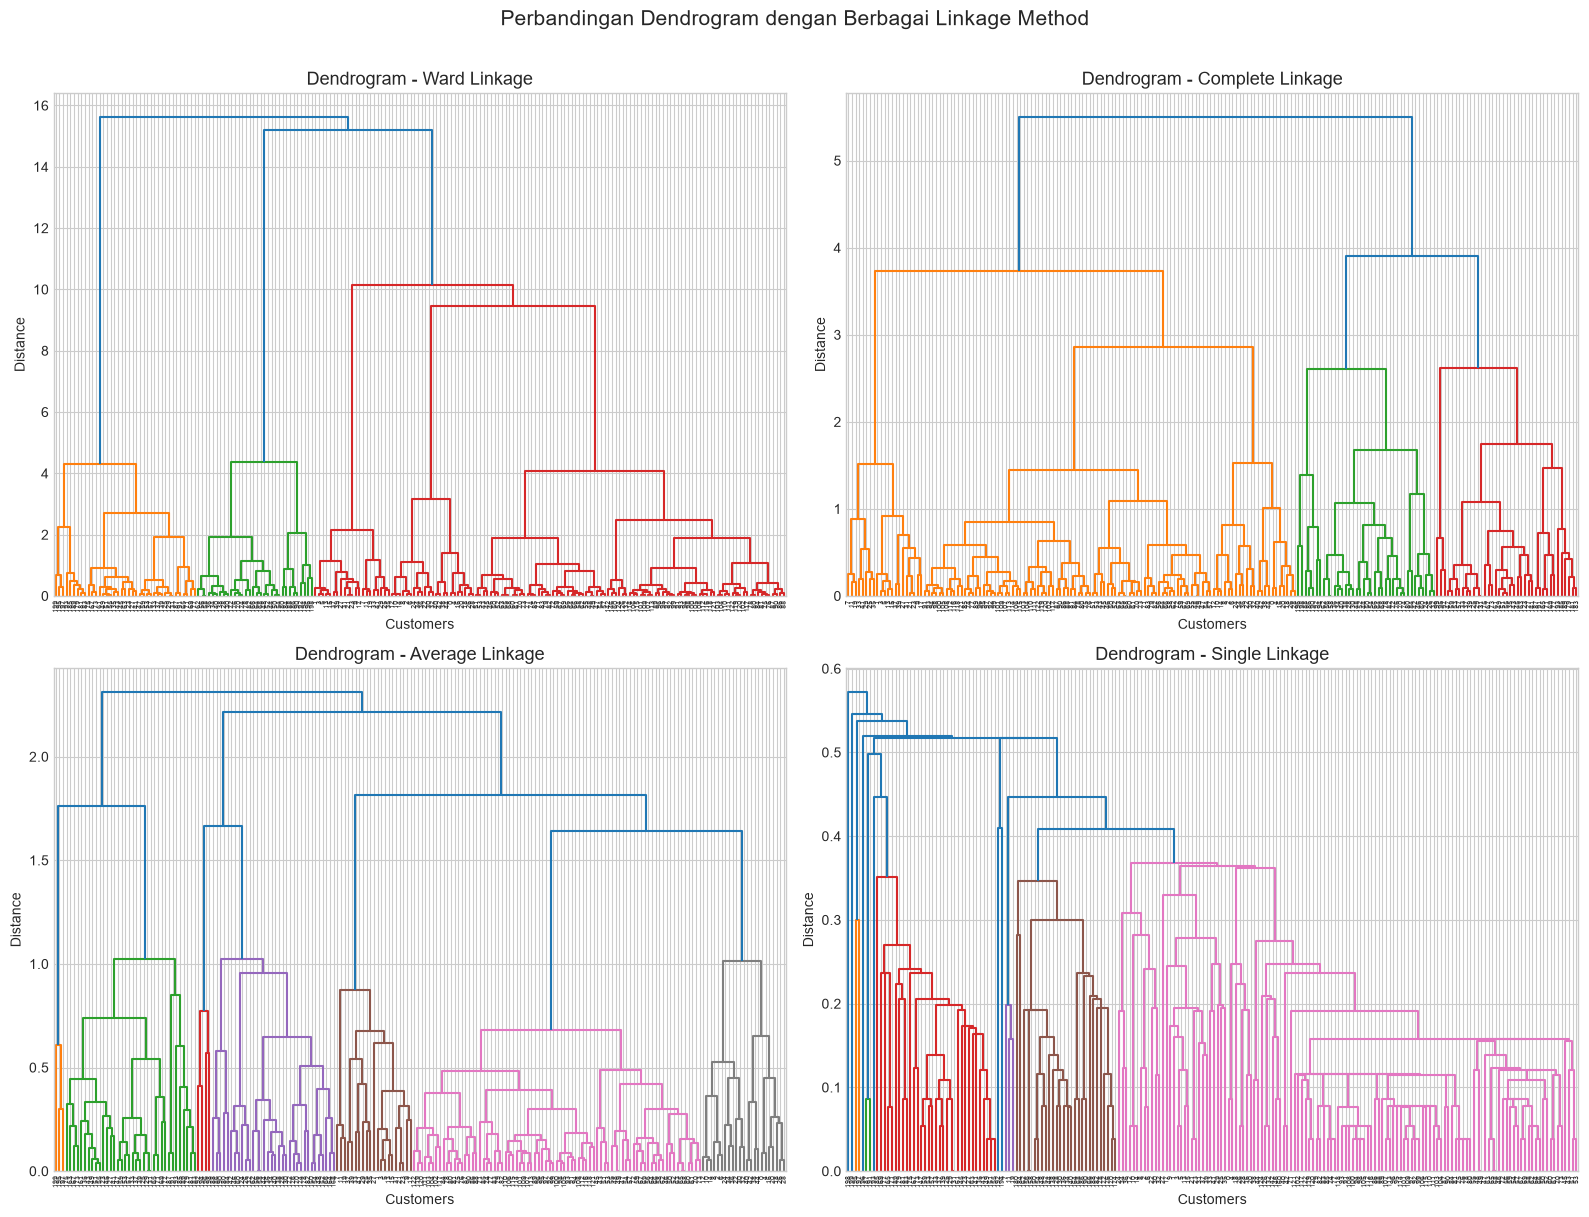

Keterangan Linkage Methods:
  Ward     : Minimizes variance dalam cluster (paling umum, cluster compact)
  Complete : Jarak maksimum antar cluster
  Average  : Jarak rata-rata antar cluster
  Single   : Jarak minimum antar cluster (sering menghasilkan chaining effect)


In [21]:
linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, method in enumerate(linkage_methods):
    ax = axes[idx // 2][idx % 2]
    sch.dendrogram(sch.linkage(X_scaled, method=method), ax=ax)
    ax.set_title(f'Dendrogram - {method.capitalize()} Linkage', fontsize=13)
    ax.set_xlabel('Customers')
    ax.set_ylabel('Distance')

plt.suptitle('Perbandingan Dendrogram dengan Berbagai Linkage Method', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('Keterangan Linkage Methods:')
print('  Ward     : Minimizes variance dalam cluster (paling umum, cluster compact)')
print('  Complete : Jarak maksimum antar cluster')
print('  Average  : Jarak rata-rata antar cluster')
print('  Single   : Jarak minimum antar cluster (sering menghasilkan chaining effect)')

## Finding Optimal Number of Clusters (Elbow Method + Silhouette Score)

k= 2  |  Inertia:     277.93  |  Silhouette Score: 0.3842
k= 3  |  Inertia:     162.62  |  Silhouette Score: 0.4610
k= 4  |  Inertia:     111.20  |  Silhouette Score: 0.4926
k= 5  |  Inertia:      66.52  |  Silhouette Score: 0.5538
k= 6  |  Inertia:      57.04  |  Silhouette Score: 0.5387
k= 7  |  Inertia:      47.76  |  Silhouette Score: 0.5198
k= 8  |  Inertia:      39.46  |  Silhouette Score: 0.4309
k= 9  |  Inertia:      34.50  |  Silhouette Score: 0.4377
k=10  |  Inertia:      30.86  |  Silhouette Score: 0.4339


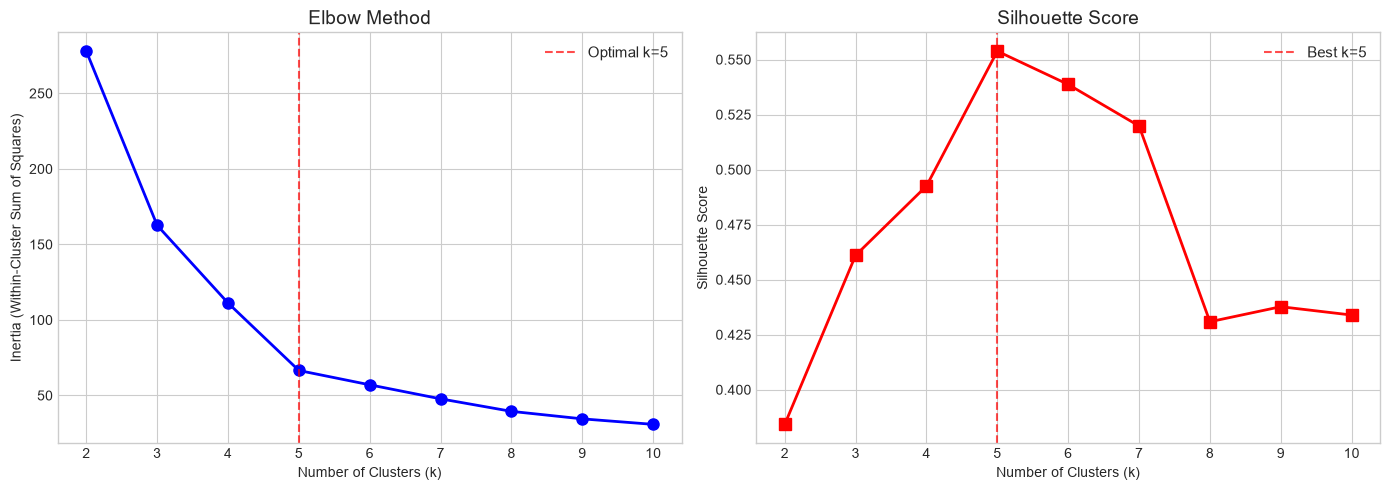


Optimal k berdasarkan Silhouette Score tertinggi: 5 (score=0.5538)


In [22]:
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(X_scaled)

    # Inertia (total jarak dalam cluster)
    inertia = 0
    for c in range(k):
        cluster_points = X_scaled[labels == c]
        centroid = cluster_points.mean(axis=0)
        inertia += np.sum((cluster_points - centroid) ** 2)
    inertias.append(inertia)

    # Silhouette Score
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f'k={k:2d}  |  Inertia: {inertia:10.2f}  |  Silhouette Score: {sil_score:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].axvline(x=5, color='r', linestyle='--', alpha=0.7, label='Optimal k=5')
axes[0].legend(fontsize=11)

axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
best_k = list(K_range)[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f'\nOptimal k berdasarkan Silhouette Score tertinggi: {best_k} (score={max(silhouette_scores):.4f})')

## Training the Hierarchical Clustering model on the dataset

In [23]:
n_clusters = 5

hc = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',
    linkage='ward'
)
y_hc = hc.fit_predict(X_scaled)

dataset['Cluster'] = y_hc

print(f'Jumlah cluster: {n_clusters}')
print(f'\nDistribusi data per cluster:')
for i in range(n_clusters):
    count = np.sum(y_hc == i)
    print(f'  Cluster {i}: {count} customers ({count/len(y_hc)*100:.1f}%)')

Jumlah cluster: 5

Distribusi data per cluster:
  Cluster 0: 32 customers (16.0%)
  Cluster 1: 39 customers (19.5%)
  Cluster 2: 85 customers (42.5%)
  Cluster 3: 21 customers (10.5%)
  Cluster 4: 23 customers (11.5%)


## Cluster Analysis & Profiling

In [24]:
cluster_summary = dataset.groupby('Cluster').agg({
    'Annual Income (k$)': ['mean', 'std', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'std', 'min', 'max'],
    'Age': ['mean', 'min', 'max'],
    'CustomerID': 'count'
}).round(2)

print('=== Ringkasan Profil per Cluster ===')
print(cluster_summary.to_string())

=== Ringkasan Profil per Cluster ===
        Annual Income (k$)                 Spending Score (1-100)                   Age         CustomerID
                      mean    std min  max                   mean    std min max   mean min max      count
Cluster                                                                                                   
0                    89.41  16.61  71  137                  15.59   8.94   1  39  41.00  19  59         32
1                    86.54  16.31  69  137                  82.13   9.36  63  97  32.69  27  40         39
2                    55.81   9.73  39   79                  49.13   7.28  29  65  42.48  18  70         85
3                    25.10   7.13  15   38                  80.05  10.25  61  99  25.33  18  35         21
4                    26.30   7.89  15   39                  20.91  13.02   3  40  45.22  19  67         23


In [25]:
cluster_means = dataset.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(2)

labels_cluster = []
for i in range(n_clusters):
    income = cluster_means.loc[i, 'Annual Income (k$)']
    spending = cluster_means.loc[i, 'Spending Score (1-100)']
    if income < 45 and spending < 45:
        label = 'Low Income - Low Spending'
    elif income < 45 and spending >= 55:
        label = 'Low Income - High Spending'
    elif income >= 55 and spending < 45:
        label = 'High Income - Low Spending'
    elif income >= 55 and spending >= 55:
        label = 'High Income - High Spending'
    else:
        label = 'Moderate Income - Moderate Spending'
    labels_cluster.append(label)
    print(f'Cluster {i}: {label} (Avg Income: {income:.1f}k$, Avg Spending: {spending:.1f}, Avg Age: {cluster_means.loc[i, "Age"]:.1f})')

Cluster 0: High Income - Low Spending (Avg Income: 89.4k$, Avg Spending: 15.6, Avg Age: 41.0)
Cluster 1: High Income - High Spending (Avg Income: 86.5k$, Avg Spending: 82.1, Avg Age: 32.7)
Cluster 2: Moderate Income - Moderate Spending (Avg Income: 55.8k$, Avg Spending: 49.1, Avg Age: 42.5)
Cluster 3: Low Income - High Spending (Avg Income: 25.1k$, Avg Spending: 80.0, Avg Age: 25.3)
Cluster 4: Low Income - Low Spending (Avg Income: 26.3k$, Avg Spending: 20.9, Avg Age: 45.2)


## Visualising the clusters

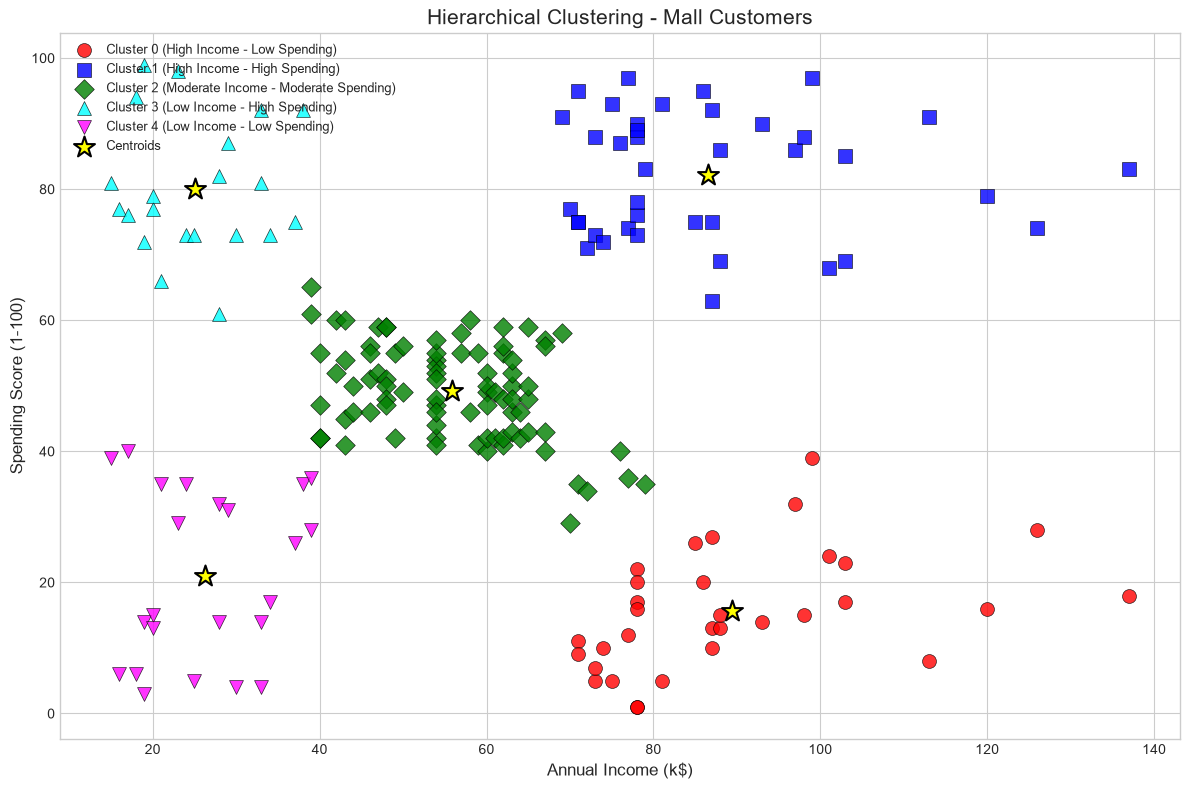

In [26]:
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
markers = ['o', 's', 'D', '^', 'v']

plt.figure(figsize=(12, 8))

for i in range(n_clusters):
    mask = y_hc == i
    plt.scatter(
        X[mask, 0], X[mask, 1],
        s=100, c=colors[i], marker=markers[i],
        label=f'Cluster {i} ({labels_cluster[i]})',
        edgecolors='black', linewidth=0.5, alpha=0.8
    )

# Plot centroids
centroids = []
for i in range(n_clusters):
    centroid = X[y_hc == i].mean(axis=0)
    centroids.append(centroid)
centroids = np.array(centroids)
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c='yellow', marker='*', edgecolors='black', linewidth=1.5, label='Centroids', zorder=5)

plt.title('Hierarchical Clustering - Mall Customers', fontsize=15)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

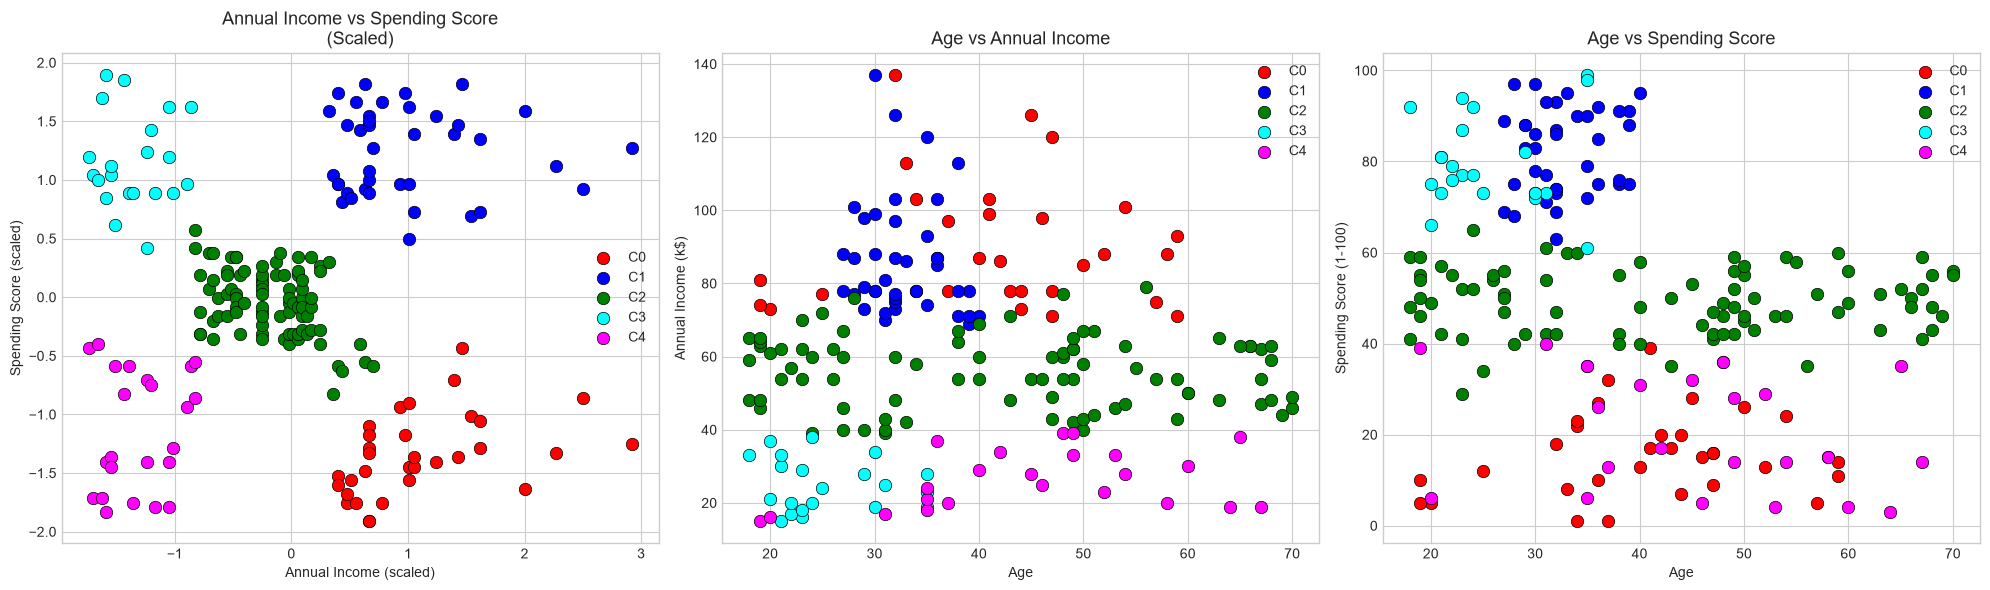

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Income vs Spending (scaled)
for i in range(n_clusters):
    mask = y_hc == i
    axes[0].scatter(X_scaled[mask, 0], X_scaled[mask, 1], s=80, c=colors[i], label=f'C{i}', edgecolors='black', linewidth=0.5)
axes[0].set_title('Annual Income vs Spending Score\n(Scaled)', fontsize=13)
axes[0].set_xlabel('Annual Income (scaled)')
axes[0].set_ylabel('Spending Score (scaled)')
axes[0].legend()

# Plot 2: Age vs Annual Income
age_income = dataset[['Age', 'Annual Income (k$)', 'Cluster']].values
for i in range(n_clusters):
    mask = age_income[:, 2] == i
    axes[1].scatter(age_income[mask, 0], age_income[mask, 1], s=80, c=colors[i], label=f'C{i}', edgecolors='black', linewidth=0.5)
axes[1].set_title('Age vs Annual Income', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Annual Income (k$)')
axes[1].legend()

# Plot 3: Age vs Spending Score
age_spending = dataset[['Age', 'Spending Score (1-100)', 'Cluster']].values
for i in range(n_clusters):
    mask = age_spending[:, 2] == i
    axes[2].scatter(age_spending[mask, 0], age_spending[mask, 1], s=80, c=colors[i], label=f'C{i}', edgecolors='black', linewidth=0.5)
axes[2].set_title('Age vs Spending Score', fontsize=13)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Spending Score (1-100)')
axes[2].legend()

plt.tight_layout()
plt.show()

## Model Evaluation

In [28]:
sil_avg = silhouette_score(X_scaled, y_hc)
sil_per_sample = silhouette_samples(X_scaled, y_hc)

print(f'=== Evaluation Metrics (k={n_clusters}) ===')
print(f'Overall Silhouette Score: {sil_avg:.4f}')
print(f'\nSilhouette Score per Cluster:')
for i in range(n_clusters):
    cluster_sil = sil_per_sample[y_hc == i]
    print(f'  Cluster {i}: mean={cluster_sil.mean():.4f}, min={cluster_sil.min():.4f}, max={cluster_sil.max():.4f}')

# Interpretasi
if sil_avg > 0.7:
    print(f'\n>> Kualitas clustering SANGAT BAIK (score > 0.7)')
elif sil_avg > 0.5:
    print(f'\n>> Kualitas clustering BAIK (score > 0.5)')
elif sil_avg > 0.25:
    print(f'\n>> Kualitas clustering CUKUP (score > 0.25)')
else:
    print(f'\n>> Kualitas clustering LEMAH (score <= 0.25)')

=== Evaluation Metrics (k=5) ===
Overall Silhouette Score: 0.5538

Silhouette Score per Cluster:
  Cluster 0: mean=0.5526, min=0.3149, max=0.6709
  Cluster 1: mean=0.5139, min=0.2383, max=0.6564
  Cluster 2: mean=0.5626, min=-0.0842, max=0.7454
  Cluster 3: mean=0.6354, min=0.2926, max=0.7403
  Cluster 4: mean=0.5162, min=0.0116, max=0.6817

>> Kualitas clustering BAIK (score > 0.5)


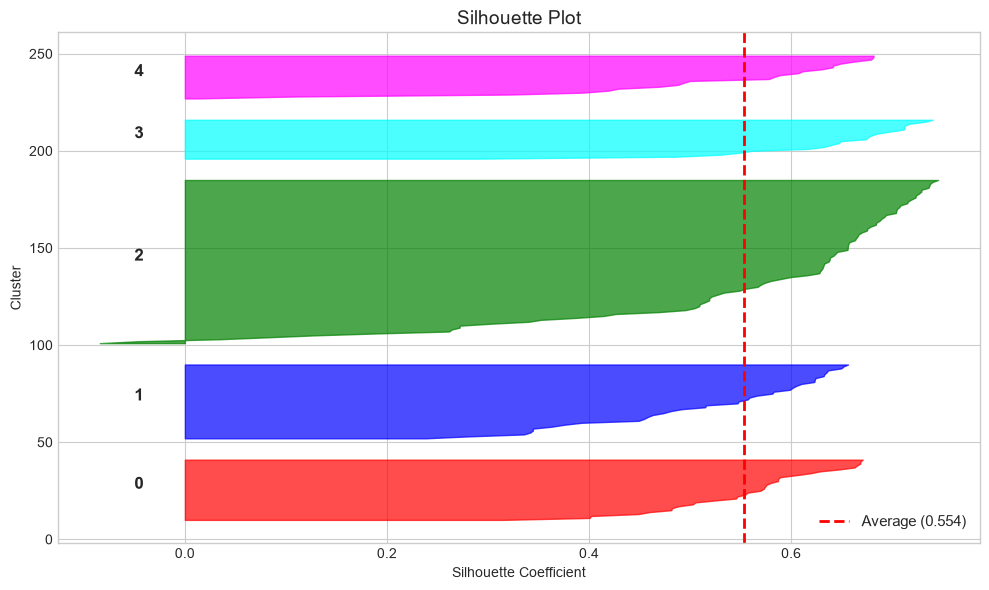

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
for i in range(n_clusters):
    cluster_sil_vals = sil_per_sample[y_hc == i]
    cluster_sil_vals.sort()

    size_cluster = cluster_sil_vals.shape[0]
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=2, label=f'Average ({sil_avg:.3f})')
ax.set_title('Silhouette Plot', fontsize=14)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Perbandingan Linkage Methods pada Data Ini

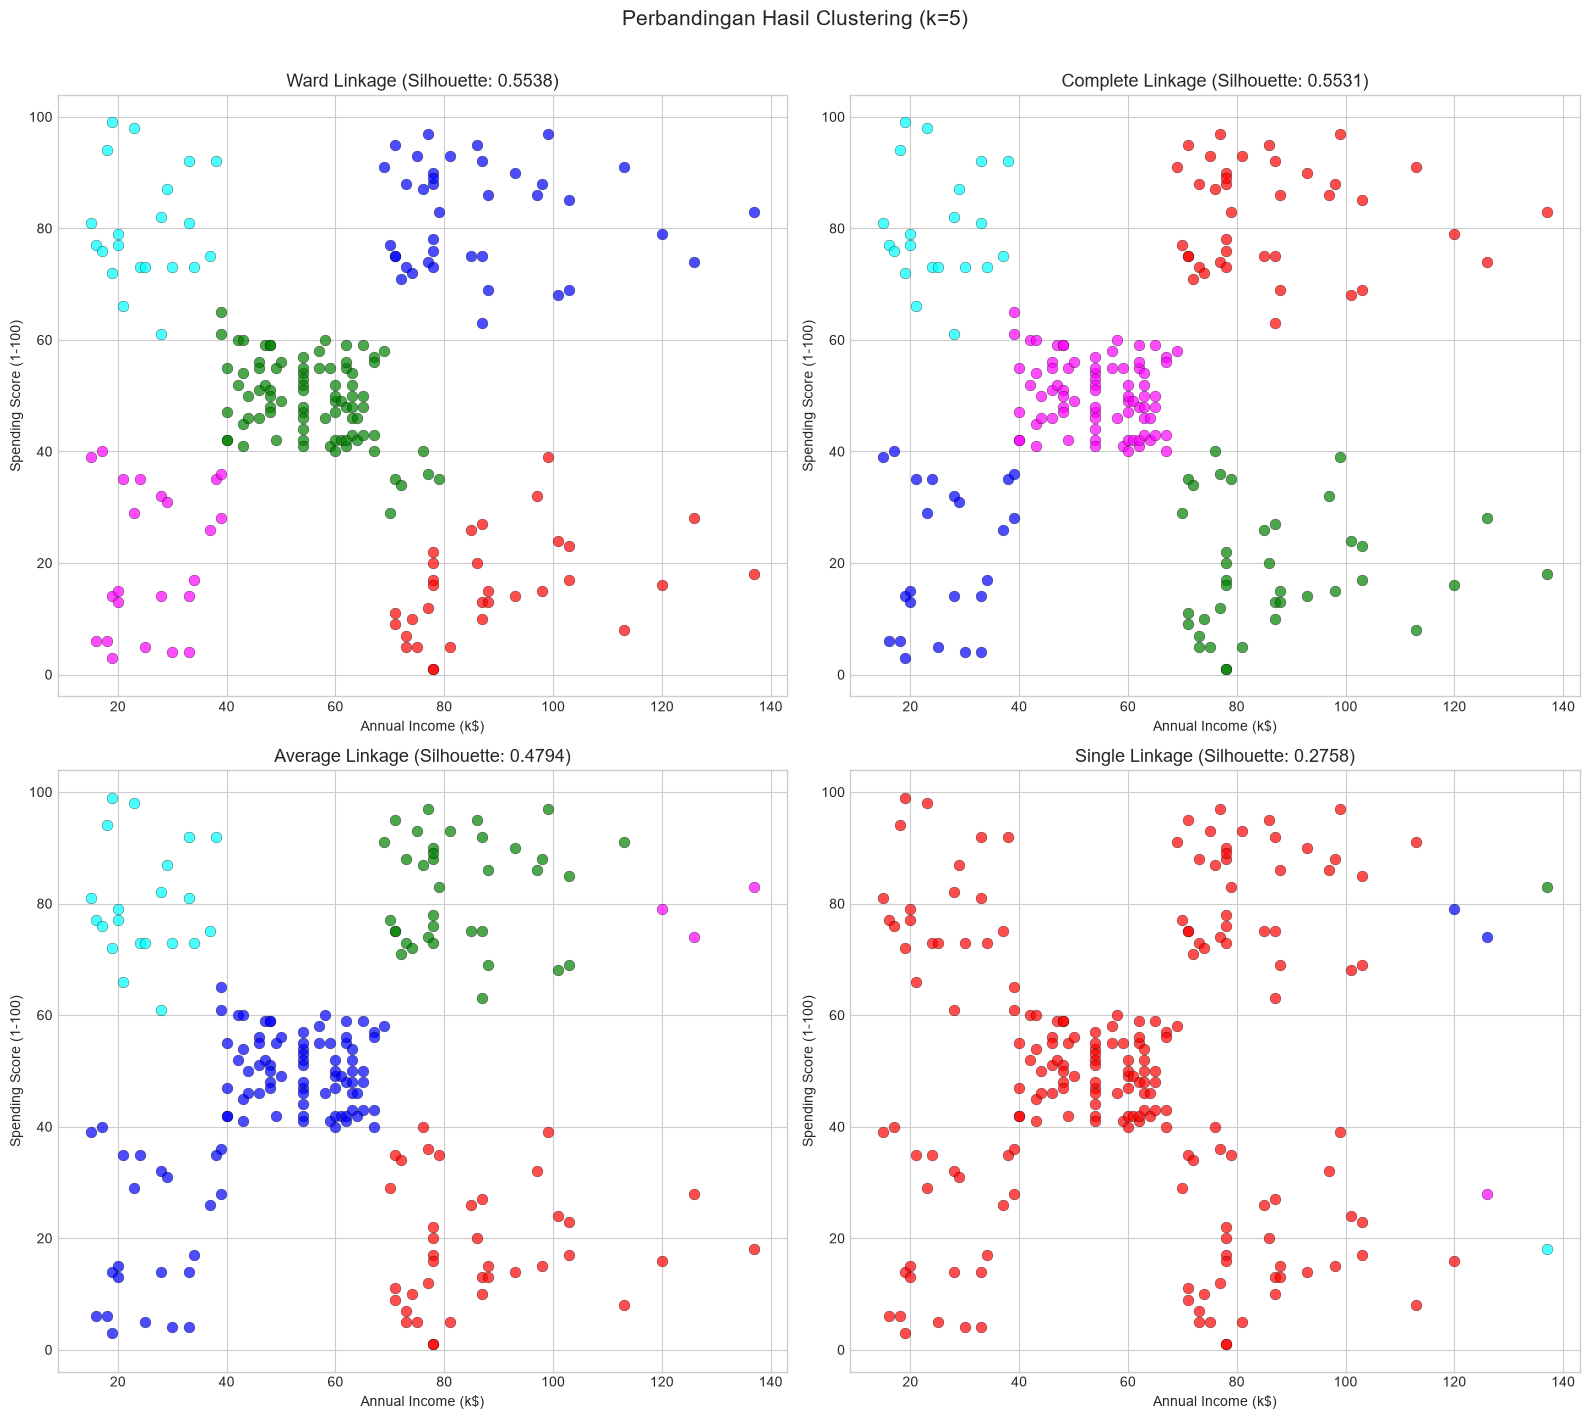


=== Ranking Linkage Methods ===
  1. Ward       -> Silhouette Score: 0.5538
  2. Complete   -> Silhouette Score: 0.5531
  3. Average    -> Silhouette Score: 0.4794
  4. Single     -> Silhouette Score: 0.2758


In [30]:
linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

results = []

for idx, method in enumerate(linkage_methods):
    ax = axes[idx // 2][idx % 2]
    hc_temp = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage=method)
    labels_temp = hc_temp.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_temp)
    results.append((method, sil))

    for i in range(n_clusters):
        mask = labels_temp == i
        ax.scatter(X[mask, 0], X[mask, 1], s=60, c=colors[i], edgecolors='black', linewidth=0.3, alpha=0.7)
    ax.set_title(f'{method.capitalize()} Linkage (Silhouette: {sil:.4f})', fontsize=13)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')

plt.suptitle(f'Perbandingan Hasil Clustering (k={n_clusters})', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('\n=== Ranking Linkage Methods ===')
results.sort(key=lambda x: x[1], reverse=True)
for rank, (method, score) in enumerate(results, 1):
    print(f'  {rank}. {method.capitalize():10s} -> Silhouette Score: {score:.4f}')

## Analisis dan Kesimpulan

In [31]:
print('=' * 65)
print('         KESIMPULAN ANALISIS HIERARCHICAL CLUSTERING')
print('=' * 65)
print()
print(f'1. Dataset: Mall Customers ({len(dataset)} customers)')
print(f'2. Fitur yang digunakan: Annual Income & Spending Score')
print(f'3. Optimal jumlah cluster: {n_clusters}')
print(f'4. Silhouette Score: {sil_avg:.4f}')
print(f'5. Linkage method terbaik: {results[0][0].capitalize()} (score: {results[0][1]:.4f})')
print()
print('Profil Cluster yang Ditemukan:')
print('-' * 65)
for i in range(n_clusters):
    n = np.sum(y_hc == i)
    inc = dataset[dataset['Cluster'] == i]['Annual Income (k$)'].mean()
    spn = dataset[dataset['Cluster'] == i]['Spending Score (1-100)'].mean()
    age = dataset[dataset['Cluster'] == i]['Age'].mean()
    print(f'  Cluster {i}: {labels_cluster[i]}')
    print(f'    -> {n} customers | Avg Income: {inc:.1f}k$ | Avg Spending: {spn:.1f} | Avg Age: {age:.1f}')

print()
print('Insight Bisnis:')
print('-' * 65)
print('  - Cluster High Income & High Spending: Target utama untuk premium products')
print('  - Cluster High Income & Low Spending: Perlu strategi marketing untuk meningkatkan spending')
print('  - Cluster Low Income & High Spending: Target untuk promosi dan diskon')
print('  - Cluster Low Income & Low Spending: Pasar potensial dengan strategi yang tepat')
print('  - Cluster Moderate: Segment middle-market, cocok untuk loyalty programs')

         KESIMPULAN ANALISIS HIERARCHICAL CLUSTERING

1. Dataset: Mall Customers (200 customers)
2. Fitur yang digunakan: Annual Income & Spending Score
3. Optimal jumlah cluster: 5
4. Silhouette Score: 0.5538
5. Linkage method terbaik: Ward (score: 0.5538)

Profil Cluster yang Ditemukan:
-----------------------------------------------------------------
  Cluster 0: High Income - Low Spending
    -> 32 customers | Avg Income: 89.4k$ | Avg Spending: 15.6 | Avg Age: 41.0
  Cluster 1: High Income - High Spending
    -> 39 customers | Avg Income: 86.5k$ | Avg Spending: 82.1 | Avg Age: 32.7
  Cluster 2: Moderate Income - Moderate Spending
    -> 85 customers | Avg Income: 55.8k$ | Avg Spending: 49.1 | Avg Age: 42.5
  Cluster 3: Low Income - High Spending
    -> 21 customers | Avg Income: 25.1k$ | Avg Spending: 80.0 | Avg Age: 25.3
  Cluster 4: Low Income - Low Spending
    -> 23 customers | Avg Income: 26.3k$ | Avg Spending: 20.9 | Avg Age: 45.2

Insight Bisnis:
----------------------------